# Customer Churn: EDA

This notebook is part of a multi-notebook customer churn project.

The goal of this notebook is to clean the Telco Customer Churn dataset and explore the major patterns associated with churn. The cleaned dataset produced here is used by the later insights, modeling, and recommendations notebooks.


## Project Notebooks

1. **Customer Churn: EDA**  
   Cleans the dataset, creates churn-related features, and explores major churn patterns.

2. **Customer Churn: Insights**  
   Builds customer segments and identifies high-risk churn groups.

3. **Customer Churn: Modeling**  
   Trains machine learning models to predict customer churn.

4. **Customer Churn: Recommendations**  
   Interprets segment and model results and turns findings into retention recommendations.


## Notebook Goals

In this notebook, we will:

- Load the raw Telco Customer Churn dataset
- Clean data quality issues, including `TotalCharges`
- Create churn-related helper columns
- Explore major churn patterns across customer, service, contract, and billing features
- Save a cleaned dataset for the later notebooks


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
import os

if os.path.exists("/kaggle/input"):
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            print(os.path.join(dirname, filename))
else:
    print("Not running on Kaggle; using local repository paths where available.")

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

kaggle_path = Path("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
local_path = PROJECT_ROOT / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if kaggle_path.exists():
    file_path = kaggle_path
elif local_path.exists():
    file_path = local_path
else:
    raise FileNotFoundError(
        "Dataset not found. On Kaggle, attach the Telco Customer Churn dataset. "
        "Locally, place WA_Fn-UseC_-Telco-Customer-Churn.csv in the data/ folder."
    )

df = pd.read_csv(file_path)

print("Loaded from:", file_path)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
df_clean.isna().sum()[df_clean.isna().sum() > 0]

Missing values after converting TotalCharges:


TotalCharges    11
dtype: int64

In [8]:
df_clean[df_clean["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [9]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print("Remaining missing values:", df_clean.isna().sum().sum())

Remaining missing values: 0


## Exploratory Data Analysis

The first goal is to understand the overall churn rate and how churn differs across customer groups.

In [10]:
df_clean["Churn_Flag"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

df_clean[["Churn", "Churn_Flag"]].head()

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [11]:
churn_counts = df_clean["Churn"].value_counts()
churn_rate = df_clean["Churn_Flag"].mean()

print(churn_counts)
print(f"\nOverall churn rate: {churn_rate:.2%}")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.54%


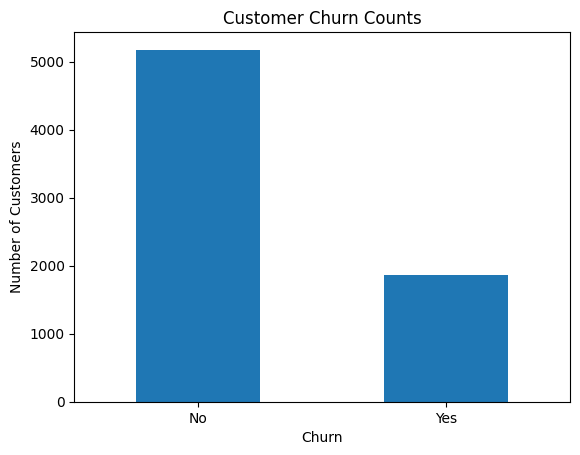

In [12]:
churn_counts.plot(kind="bar")
plt.title("Customer Churn Counts")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [13]:
contract_churn = (
    df_clean
    .groupby("Contract")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
    .sort_values("Churn_Rate", ascending=False)
)

contract_churn["Churn_Rate_%"] = contract_churn["Churn_Rate"] * 100

contract_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
Contract,,
Month-to-month,3875,42.709677
One year,1473,11.269518
Two year,1695,2.831858


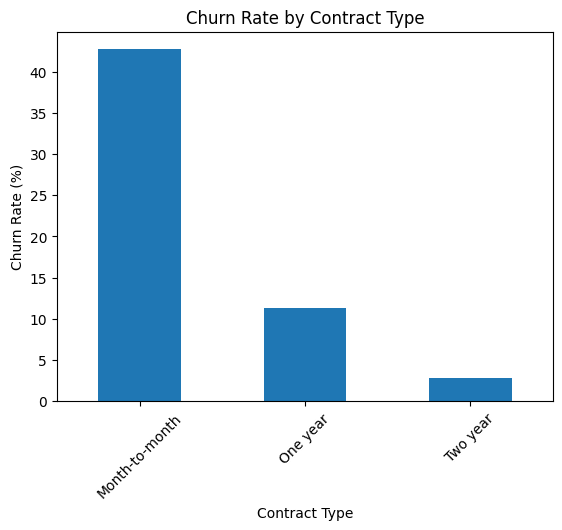

In [14]:
contract_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Churn by Tenure

Next, we analyze whether newer customers are more likely to churn than long-term customers.

In [15]:
df_clean["Tenure_Group"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn = (
    df_clean
    .groupby("Tenure_Group", observed=False)["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
)

tenure_churn["Churn_Rate_%"] = tenure_churn["Churn_Rate"] * 100

tenure_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
Tenure_Group,,
0-12 months,2186,47.438243
13-24 months,1024,28.710938
25-48 months,1594,20.388959
49-72 months,2239,9.513176


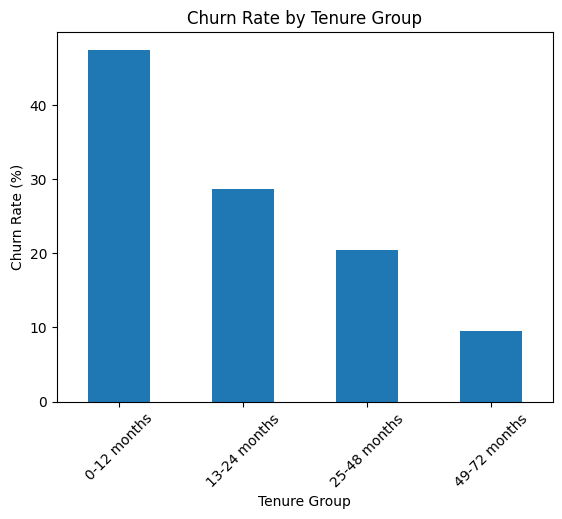

In [16]:
tenure_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Churn by Monthly Charges

This section checks whether customers with higher monthly charges are more likely to churn.

In [17]:
df_clean.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


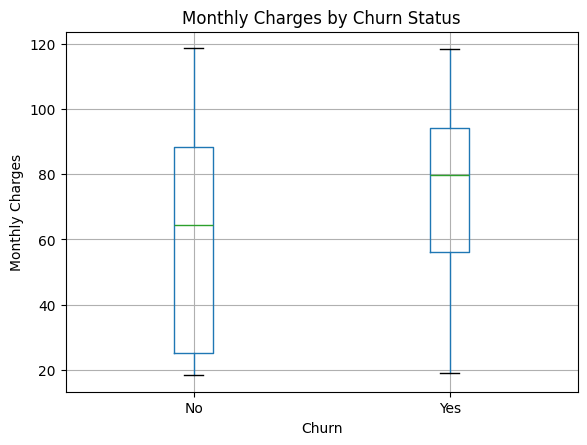

In [18]:
df_clean.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [19]:
internet_churn = (
    df_clean
    .groupby("InternetService")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
    .sort_values("Churn_Rate", ascending=False)
)

internet_churn["Churn_Rate_%"] = internet_churn["Churn_Rate"] * 100

internet_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
InternetService,,
Fiber optic,3096,41.892765
DSL,2421,18.959108
No,1526,7.404980


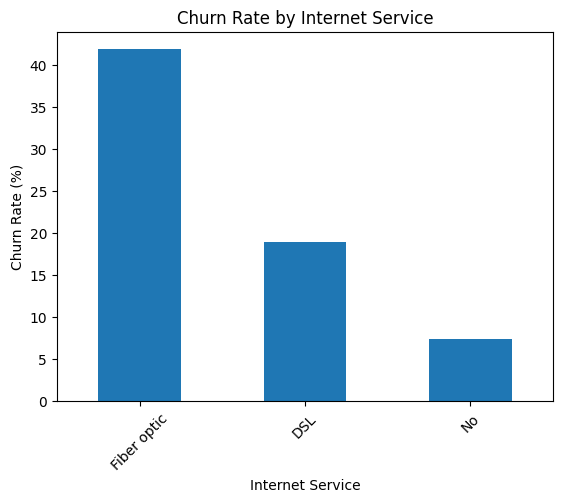

In [20]:
internet_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [21]:
payment_churn = (
    df_clean
    .groupby("PaymentMethod")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
    .sort_values("Churn_Rate", ascending=False)
)

payment_churn["Churn_Rate_%"] = payment_churn["Churn_Rate"] * 100

payment_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
PaymentMethod,,
Electronic check,2365,45.285412
Mailed check,1612,19.106700
Bank transfer (automatic),1544,16.709845
Credit card (automatic),1522,15.243101


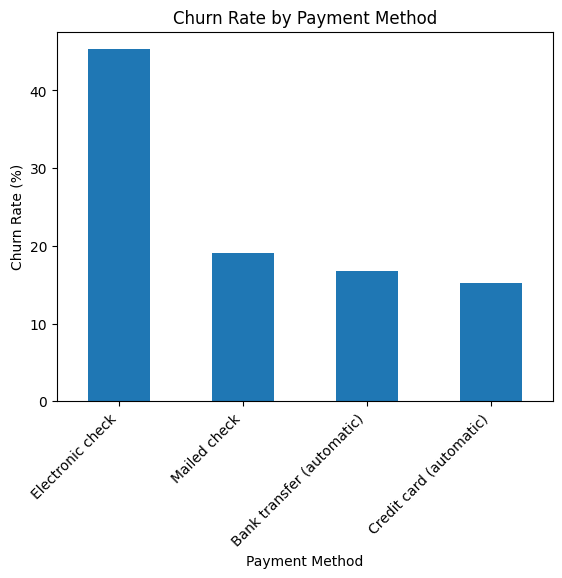

In [22]:
payment_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Initial EDA Findings

The initial analysis shows that churn is strongly related to contract type, customer tenure, monthly charges, internet service, and payment method.

Customers on month-to-month contracts have the highest churn rate, while customers on two-year contracts have the lowest churn rate. This suggests that longer contracts may be associated with stronger customer retention.

Newer customers are also more likely to churn. Customers with 0-12 months of tenure have a much higher churn rate than long-term customers, which suggests that the early customer experience may be important for retention.

Churned customers also have higher average monthly charges than non-churned customers. This may indicate that price sensitivity or perceived value plays a role in churn.

Fiber optic customers and customers using electronic checks show especially high churn rates. These groups may require deeper analysis because they represent potential high-risk customer segments.

In [23]:
def churn_summary(column):
    summary = (
        df_clean
        .groupby(column)["Churn_Flag"]
        .agg(Customer_Count="count", Churn_Rate="mean")
        .sort_values("Churn_Rate", ascending=False)
    )

    summary["Churn_Rate_%"] = summary["Churn_Rate"] * 100

    return summary[["Customer_Count", "Churn_Rate_%"]]

In [24]:
churn_summary("OnlineSecurity")

,Customer_Count,Churn_Rate_%
OnlineSecurity,,
No,3498,41.766724
Yes,2019,14.611194
No internet service,1526,7.404980


In [25]:
churn_summary("TechSupport")

,Customer_Count,Churn_Rate_%
TechSupport,,
No,3473,41.635474
Yes,2044,15.166341
No internet service,1526,7.404980


In [26]:
churn_summary("OnlineBackup")

,Customer_Count,Churn_Rate_%
OnlineBackup,,
No,3088,39.928756
Yes,2429,21.531494
No internet service,1526,7.404980


In [27]:
churn_summary("DeviceProtection")

,Customer_Count,Churn_Rate_%
DeviceProtection,,
No,3095,39.127625
Yes,2422,22.502064
No internet service,1526,7.404980


In [28]:
churn_summary("PaperlessBilling")

,Customer_Count,Churn_Rate_%
PaperlessBilling,,
Yes,4171,33.565092
No,2872,16.330084


In [29]:
df_clean["Risk_Factor_Count"] = 0

df_clean["Risk_Factor_Count"] += (df_clean["Contract"] == "Month-to-month").astype(int)
df_clean["Risk_Factor_Count"] += (df_clean["tenure"] <= 12).astype(int)
df_clean["Risk_Factor_Count"] += (df_clean["InternetService"] == "Fiber optic").astype(int)
df_clean["Risk_Factor_Count"] += (df_clean["PaymentMethod"] == "Electronic check").astype(int)
df_clean["Risk_Factor_Count"] += (df_clean["MonthlyCharges"] > df_clean["MonthlyCharges"].median()).astype(int)

risk_churn = (
    df_clean
    .groupby("Risk_Factor_Count")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
)

risk_churn["Churn_Rate_%"] = risk_churn["Churn_Rate"] * 100

risk_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
Risk_Factor_Count,,
0,1376,2.543605
1,1150,8.347826
2,1762,20.488082
3,1197,34.837093
4,1018,56.188605
5,540,71.851852


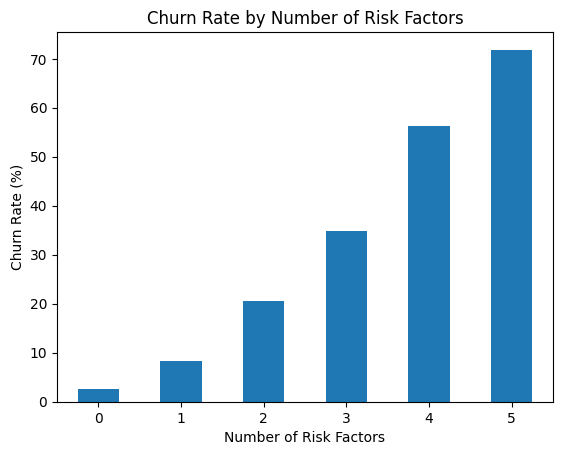

In [30]:
risk_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Number of Risk Factors")
plt.xlabel("Number of Risk Factors")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Service Feature Findings

Service-related features show clear churn patterns. Customers without online security, tech support, online backup, or device protection have noticeably higher churn rates than customers who have those services.

The strongest service-related churn signals are online security and tech support. Customers without online security churn at about 41.77%, compared with about 14.61% for customers with online security. Customers without tech support churn at about 41.64%, compared with about 15.17% for customers with tech support.

This suggests that customers who receive more support, protection, or account value from the company may be more likely to stay.

## Risk Factor Analysis

A simple risk factor score was created using five churn-related conditions:

- Month-to-month contract
- Tenure of 12 months or less
- Fiber optic internet service
- Electronic check payment method
- Monthly charges above the median

The churn rate increases sharply as the number of risk factors increases. Customers with no risk factors churn at only 2.54%, while customers with all five risk factors churn at 71.85%.

This does not replace a machine learning model, but it provides a clear business-friendly way to explain churn risk. It shows that churn is not driven by one single variable. Instead, customers become much more likely to churn when multiple risk factors appear together.

## EDA Conclusion

This notebook cleaned the Telco Customer Churn dataset and explored the main factors associated with customer churn.

The overall churn rate is 26.54%. The analysis found that churn is especially high among month-to-month customers, newer customers, fiber optic customers, electronic check users, customers with higher monthly charges, and customers without support or protection services.

The most important early findings are:

1. Month-to-month customers have much higher churn than one-year or two-year contract customers.
2. New customers are at greater risk, especially those with 0-12 months of tenure.
3. Churned customers tend to have higher monthly charges.
4. Fiber optic customers and electronic check users show high churn rates.
5. Customers without online security or tech support are more likely to churn.
6. Churn risk increases sharply when multiple risk factors are combined.

These findings will guide the next stage of the project, where customer segments and business recommendations will be developed before building machine learning models to predict churn.

In [31]:
from pathlib import Path

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else PROJECT_ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "telco_churn_cleaned.csv"
df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved as {output_path}")
print("Final shape:", df_clean.shape)

Cleaned dataset saved as telco_churn_cleaned.csv
Final shape: (7043, 24)
